<a href="https://colab.research.google.com/github/harshithachanta/Linearregression/blob/main/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Linear Regression Hands-On**

Drivelink of dataset :https://drive.google.com/file/d/1MH1kBcyO46qh4KB8a4oNfuCleUTur_o6/view?usp=drive_link

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

# 1) Upload data


In [82]:
df=pd.read_csv('new_insurance_data.csv')


In [83]:
print(df)

       age     sex     bmi  children smoker  Claim_Amount  past_consultations  \
0     18.0    male  23.210       0.0     no   29087.54313                17.0   
1     18.0    male  30.140       0.0     no   39053.67437                 7.0   
2     18.0    male  33.330       0.0     no   39023.62759                19.0   
3     18.0    male  33.660       0.0     no   28185.39332                11.0   
4     18.0    male  34.100       0.0     no   14697.85941                16.0   
...    ...     ...     ...       ...    ...           ...                 ...   
1333  33.0  female  35.530       0.0    yes   63142.25346                32.0   
1334  31.0  female  38.095       1.0    yes   43419.95227                31.0   
1335  52.0    male  34.485       3.0    yes   52458.92353                25.0   
1336  45.0    male  30.360       0.0    yes   69927.51664                34.0   
1337  54.0  female  47.410       0.0    yes   63982.80926                31.0   

      num_of_steps  Hospita

# 2) Analysing and Cleaning Data

In [84]:
print(df.head())

    age   sex    bmi  children smoker  Claim_Amount  past_consultations  \
0  18.0  male  23.21       0.0     no   29087.54313                17.0   
1  18.0  male  30.14       0.0     no   39053.67437                 7.0   
2  18.0  male  33.33       0.0     no   39023.62759                19.0   
3  18.0  male  33.66       0.0     no   28185.39332                11.0   
4  18.0  male  34.10       0.0     no   14697.85941                16.0   

   num_of_steps  Hospital_expenditure  NUmber_of_past_hospitalizations  \
0      715428.0           4720920.992                              0.0   
1      699157.0           4329831.676                              0.0   
2      702341.0           6884860.774                              0.0   
3      700250.0           4274773.550                              0.0   
4      711584.0           3787293.921                              0.0   

   Anual_Salary     region    charges  
0   55784970.05  southeast  1121.8739  
1   13700885.19  southea

In [85]:
print(df.describe())

               age          bmi     children  Claim_Amount  \
count  1329.000000  1335.000000  1333.000000   1324.000000   
mean     39.310008    30.665112     1.090773  33361.327180   
std      14.034818     6.101690     1.201856  15617.288337   
min      18.000000    15.960000     0.000000   1920.136268   
25%      27.000000    26.302500     0.000000  20768.860390   
50%      39.000000    30.400000     1.000000  33700.310675   
75%      51.000000    34.687500     2.000000  45052.331957   
max      64.000000    53.130000     5.000000  77277.988480   

       past_consultations  num_of_steps  Hospital_expenditure  \
count         1332.000000  1.335000e+03          1.334000e+03   
mean            15.216216  9.100047e+05          1.584179e+07   
std              7.467723  9.188612e+04          2.669305e+07   
min              1.000000  6.954300e+05          2.945253e+04   
25%              9.000000  8.471995e+05          4.077633e+06   
50%             15.000000  9.143000e+05          7.

In [86]:
print(df.shape)

rows=df.shape[0]
cols=df.shape[1]


(1338, 13)


In [87]:
print(df.columns)

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'Claim_Amount',
       'past_consultations', 'num_of_steps', 'Hospital_expenditure',
       'NUmber_of_past_hospitalizations', 'Anual_Salary', 'region', 'charges'],
      dtype='object')


**Cheking Null values**

In [88]:
print(df.isna().sum())

age                                 9
sex                                 0
bmi                                 3
children                            5
smoker                              0
Claim_Amount                       14
past_consultations                  6
num_of_steps                        3
Hospital_expenditure                4
NUmber_of_past_hospitalizations     2
Anual_Salary                        6
region                              0
charges                             0
dtype: int64


In [89]:
print(df.isna().sum().sum())
sum_na=df.isna().sum().sum()

52


In [90]:
df.dropna(inplace=True)

In [91]:
print(df.isna().sum().sum())

0


Checking duplicate rows

In [92]:
print(df.duplicated().sum())

0


**Outliers**

Extremely high or extremely low values

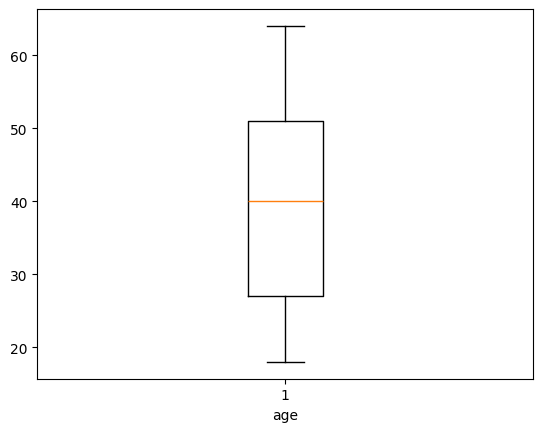

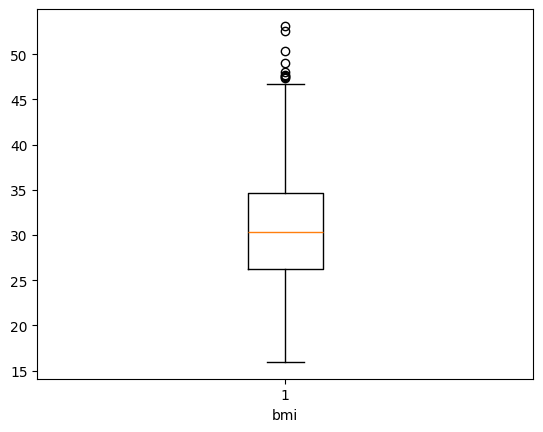

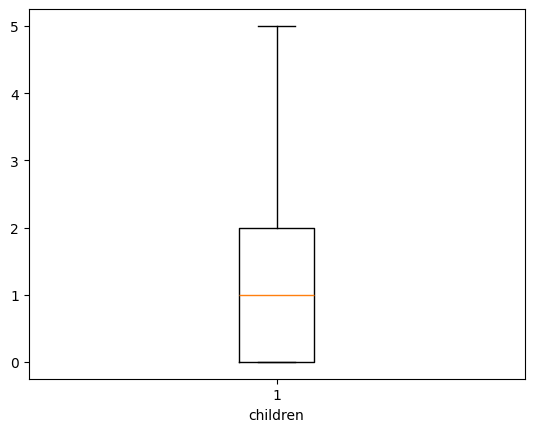

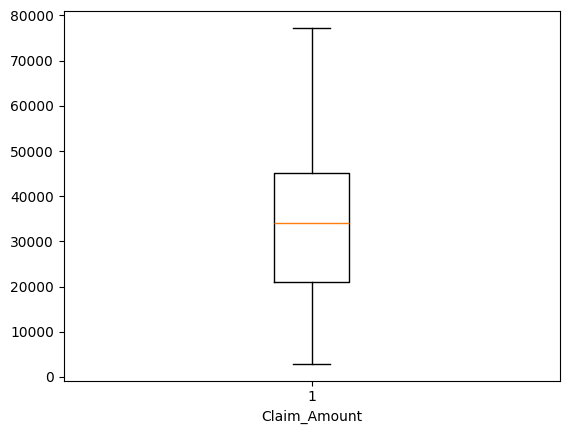

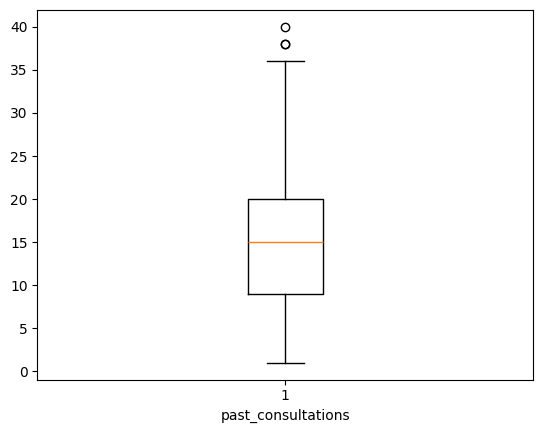

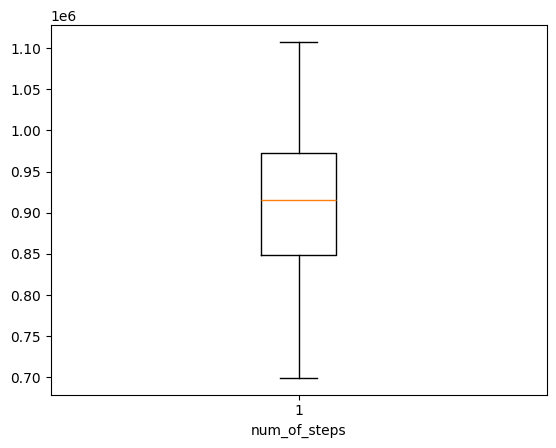

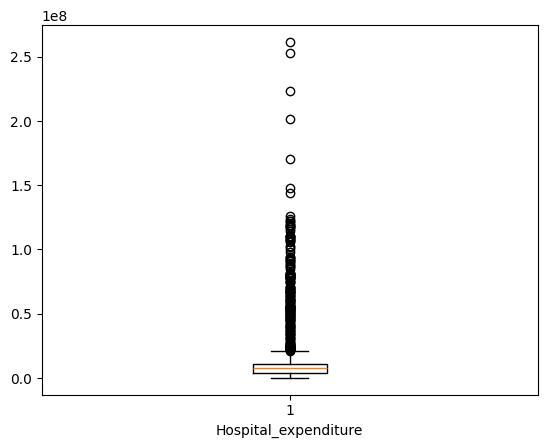

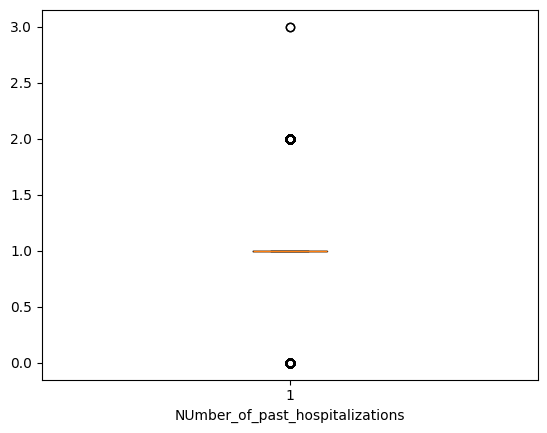

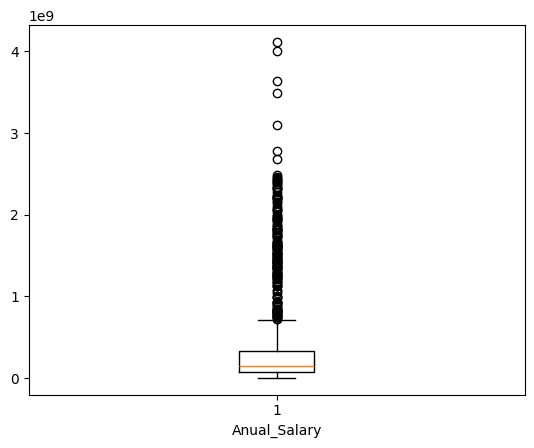

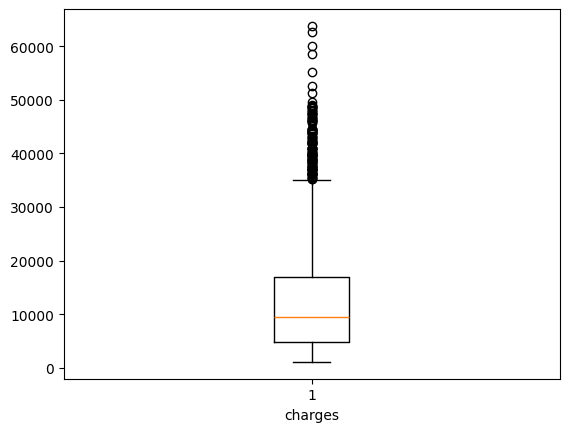

In [93]:
#create box plot for each columns to check for outlier
for i in df.columns:
  if df[i].dtypes=="int" or df[i].dtypes=="float":
     plt.boxplot(df[i])
     plt.xlabel(i)
     plt.show()

**Do I remove the outlier?**

**Outliers can happen because of->**

1) data entry error

2) data measurement error and device error

3) natural extremes

**We will not remove the outliers**

Because outliers are important here, this data can have naturally extreme values.



**Independent Variable( Column)- Input**

They are the columns which decide the output or the dependent data. They are the columns which will be used to predict the dependent col. Ex-> Exp, Study Hours, Backlogs, Cgpa

**Dependent Variable( column)- Output/Result**

This what we are trying to predict.
This is dependent on the independent columns.
Eg- Salary, etc




# Multicollinearity

When there are two or more independent columns or variables are there which are highly correlated with each other. This condtion is called multicollinearity.

Eg-> Independent= Age, Exp, Hours_study, Backlog, Cpga
    
     -Dependent= Salary

**Correlated**-> change in one will result a change in other too.

1) Exp will increase with age( so correlated)

2) Cgpa will increase/decrease with Hours_study

3) Backlogs will decrease with hours_study

**Effect of Multicollinearity**

If we have multicollinearity, there are going to be multiple columns which will have same effect on the dependent column.


1) THis will not have any issue on the prediction of numerical column

2) But, this will effect the feature importance, because when we have multiple columns effecting the output in a same way, model gets confused on which to give more importance.

Age and Exp are correlated

Age increase-> salary increase

Exp increase-> salary increase


Age and Exp are having same effect on Salary

# VIF

Variance Inflation Factor

Used to check for Multicollinearity.

Higher the VIF-> more than column is correlated with other columns.

Vif > 5 is high



In [94]:
print(df.head())

    age   sex    bmi  children smoker  Claim_Amount  past_consultations  \
0  18.0  male  23.21       0.0     no   29087.54313                17.0   
1  18.0  male  30.14       0.0     no   39053.67437                 7.0   
2  18.0  male  33.33       0.0     no   39023.62759                19.0   
3  18.0  male  33.66       0.0     no   28185.39332                11.0   
4  18.0  male  34.10       0.0     no   14697.85941                16.0   

   num_of_steps  Hospital_expenditure  NUmber_of_past_hospitalizations  \
0      715428.0           4720920.992                              0.0   
1      699157.0           4329831.676                              0.0   
2      702341.0           6884860.774                              0.0   
3      700250.0           4274773.550                              0.0   
4      711584.0           3787293.921                              0.0   

   Anual_Salary     region    charges  
0   55784970.05  southeast  1121.8739  
1   13700885.19  southea

In [95]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
cols=[]
for i in df.columns:
  if df[i].dtypes!="object" and i!="charges":
    cols.append(i)
print(cols)
data=df[cols]
print(data)

vif=pd.DataFrame()
vif["Columns"]=data.columns
vif["VIF"]=0

vif_values=[]
for i in range(len(cols)): # i-> 0,1,2,3,....n
  v=variance_inflation_factor(data.values,i)
  vif_values.append(v)

vif["VIF"]=vif_values

print(vif)

['age', 'bmi', 'children', 'Claim_Amount', 'past_consultations', 'num_of_steps', 'Hospital_expenditure', 'NUmber_of_past_hospitalizations', 'Anual_Salary']
       age     bmi  children  Claim_Amount  past_consultations  num_of_steps  \
0     18.0  23.210       0.0   29087.54313                17.0      715428.0   
1     18.0  30.140       0.0   39053.67437                 7.0      699157.0   
2     18.0  33.330       0.0   39023.62759                19.0      702341.0   
3     18.0  33.660       0.0   28185.39332                11.0      700250.0   
4     18.0  34.100       0.0   14697.85941                16.0      711584.0   
...    ...     ...       ...           ...                 ...           ...   
1333  33.0  35.530       0.0   63142.25346                32.0     1091267.0   
1334  31.0  38.095       1.0   43419.95227                31.0     1107872.0   
1335  52.0  34.485       3.0   52458.92353                25.0     1092005.0   
1336  45.0  30.360       0.0   69927.51664  

In [96]:
d=df.copy()

In [97]:
df=df.drop(["num_of_steps"],axis=1)

In [98]:
cols=[]
for i in df.columns:
  if df[i].dtypes!="object" and i!="charges":
    cols.append(i)

data=df[cols]

vif=pd.DataFrame()
vif["Columns"]=data.columns
vif["VIF"]=0

vif_values=[]
for i in range(len(cols)): # i-> 0,1,2,3,....n
  v=variance_inflation_factor(data.values,i)
  vif_values.append(v)

vif["VIF"]=vif_values

print(vif)

                           Columns        VIF
0                              age  10.094843
1                              bmi  12.336735
2                         children   1.944907
3                     Claim_Amount   6.389117
4               past_consultations   7.746533
5             Hospital_expenditure  27.374979
6  NUmber_of_past_hospitalizations  15.364271
7                     Anual_Salary  37.876016


In [99]:
df=df.drop(["Anual_Salary"],axis=1)

In [100]:
cols=[]
for i in df.columns:
  if df[i].dtypes!="object" and i!="charges":
    cols.append(i)

data=df[cols]

vif=pd.DataFrame()
vif["Columns"]=data.columns
vif["VIF"]=0

vif_values=[]
for i in range(len(cols)): # i-> 0,1,2,3,....n
  v=variance_inflation_factor(data.values,i)
  vif_values.append(v)

vif["VIF"]=vif_values

print(vif)

                           Columns        VIF
0                              age   9.873895
1                              bmi  11.182301
2                         children   1.914599
3                     Claim_Amount   6.364278
4               past_consultations   7.324500
5             Hospital_expenditure   2.579248
6  NUmber_of_past_hospitalizations  11.478975


In [101]:
df=df.drop(["NUmber_of_past_hospitalizations"],axis=1)

In [102]:
cols=[]
for i in df.columns:
  if df[i].dtypes!="object" and i!="charges":
    cols.append(i)

data=df[cols]

vif=pd.DataFrame()
vif["Columns"]=data.columns
vif["VIF"]=0

vif_values=[]
for i in range(len(cols)): # i-> 0,1,2,3,....n
  v=variance_inflation_factor(data.values,i)
  vif_values.append(v)

vif["VIF"]=vif_values

print(vif)

                Columns        VIF
0                   age   8.309772
1                   bmi  11.154995
2              children   1.818798
3          Claim_Amount   6.088357
4    past_consultations   6.919598
5  Hospital_expenditure   1.909801


In [103]:
df=df.drop(["bmi"],axis=1)

In [104]:
cols=[]
for i in df.columns:
  if df[i].dtypes!="object" and i!="charges":
    cols.append(i)

data=df[cols]

vif=pd.DataFrame()
vif["Columns"]=data.columns
vif["VIF"]=0

vif_values=[]
for i in range(len(cols)): # i-> 0,1,2,3,....n
  v=variance_inflation_factor(data.values,i)
  vif_values.append(v)

vif["VIF"]=vif_values

print(vif)

                Columns       VIF
0                   age  5.753673
1              children  1.786858
2          Claim_Amount  5.313145
3    past_consultations  6.272636
4  Hospital_expenditure  1.891579


In [105]:
print(df)

       age     sex  children smoker  Claim_Amount  past_consultations  \
0     18.0    male       0.0     no   29087.54313                17.0   
1     18.0    male       0.0     no   39053.67437                 7.0   
2     18.0    male       0.0     no   39023.62759                19.0   
3     18.0    male       0.0     no   28185.39332                11.0   
4     18.0    male       0.0     no   14697.85941                16.0   
...    ...     ...       ...    ...           ...                 ...   
1333  33.0  female       0.0    yes   63142.25346                32.0   
1334  31.0  female       1.0    yes   43419.95227                31.0   
1335  52.0    male       3.0    yes   52458.92353                25.0   
1336  45.0    male       0.0    yes   69927.51664                34.0   
1337  54.0  female       0.0    yes   63982.80926                31.0   

      Hospital_expenditure     region      charges  
0             4.720921e+06  southeast   1121.87390  
1             4.3

# Label encoding

Is a way to convert categorical(text) columns to numerical columns.

Because most of the ML models work with numbers.

In [106]:
from sklearn.preprocessing import LabelEncoder

In [107]:
le=LabelEncoder()

for i in df.columns:
  if df[i].dtypes=="object":
    df[i]=le.fit_transform(df[i])

In [108]:
print(df)

       age  sex  children  smoker  Claim_Amount  past_consultations  \
0     18.0    1       0.0       0   29087.54313                17.0   
1     18.0    1       0.0       0   39053.67437                 7.0   
2     18.0    1       0.0       0   39023.62759                19.0   
3     18.0    1       0.0       0   28185.39332                11.0   
4     18.0    1       0.0       0   14697.85941                16.0   
...    ...  ...       ...     ...           ...                 ...   
1333  33.0    0       0.0       1   63142.25346                32.0   
1334  31.0    0       1.0       1   43419.95227                31.0   
1335  52.0    1       3.0       1   52458.92353                25.0   
1336  45.0    1       0.0       1   69927.51664                34.0   
1337  54.0    0       0.0       1   63982.80926                31.0   

      Hospital_expenditure  region      charges  
0             4.720921e+06       2   1121.87390  
1             4.329832e+06       2   1131.50660

# Splitting data into independent(input) and dependent(output)

In [109]:
print(df.columns)

Index(['age', 'sex', 'children', 'smoker', 'Claim_Amount',
       'past_consultations', 'Hospital_expenditure', 'region', 'charges'],
      dtype='object')


In [110]:
x=df.loc[:,['age', 'sex', 'children', 'smoker', 'Claim_Amount',
       'past_consultations', 'Hospital_expenditure', 'region']]

#                            or

# X = df.drop('charges', axis=1)   # all columns except output/target

# Y = df['charges']                # only output column

In [111]:
y=df['charges']

In [112]:
x # indepedent

,age,sex,children,smoker,Claim_Amount,past_consultations,Hospital_expenditure,region
0,18.0,1,0.0,0,29087.54313,17.0,4.720921e+06,2
1,18.0,1,0.0,0,39053.67437,7.0,4.329832e+06,2
2,18.0,1,0.0,0,39023.62759,19.0,6.884861e+06,2
3,18.0,1,0.0,0,28185.39332,11.0,4.274774e+06,2
4,18.0,1,0.0,0,14697.85941,16.0,3.787294e+06,2
...,...,...,...,...,...,...,...,...
1333,33.0,0,0.0,1,63142.25346,32.0,1.703805e+08,1
1334,31.0,0,1.0,1,43419.95227,31.0,2.015152e+08,0
1335,52.0,1,3.0,1,52458.92353,25.0,2.236450e+08,1
1336,45.0,1,0.0,1,69927.51664,34.0,2.528924e+08,2


In [113]:
y # dependent

,charges
0,1121.87390
1,1131.50660
2,1135.94070
3,1136.39940
4,1137.01100
...,...
1333,55135.40209
1334,58571.07448
1335,60021.39897
1336,62592.87309


# Train and Test Split

In [114]:
from sklearn.model_selection import train_test_split

# x-> input
# y-> output

# 100 - total
# 80 Q/A ->  X_train=Q, Y_Train-> A
# 20 Q/A ->  X_Test= Test Q

#  Y_test=Actual Answers(outputs) for X_Test
#  Y_pred
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [115]:
x_train

,age,sex,children,smoker,Claim_Amount,past_consultations,Hospital_expenditure,region
1107,19.0,1,2.0,0,23156.869190,26.0,2.054810e+07,1
402,38.0,1,1.0,0,38569.999590,18.0,2.771506e+06,3
875,60.0,1,0.0,0,41844.564980,8.0,1.191697e+07,1
384,31.0,0,2.0,0,29946.321440,15.0,4.697700e+06,1
148,27.0,1,0.0,0,15140.995230,9.0,2.957529e+06,3
...,...,...,...,...,...,...,...,...
550,44.0,0,1.0,0,19418.243310,20.0,5.127457e+06,3
376,32.0,1,3.0,0,4203.109713,20.0,7.268860e+06,3
127,22.0,1,0.0,0,17872.448030,15.0,7.946878e+06,0
776,56.0,0,0.0,0,45887.112090,13.0,1.428394e+06,3


In [116]:
y_train

,charges
1107,22493.65964
402,5488.26200
875,12523.60480
384,5327.40025
148,2494.02200
...,...
550,7626.99300
376,5253.52400
127,2254.79670
776,11073.17600


In [117]:
x_test

,age,sex,children,smoker,Claim_Amount,past_consultations,Hospital_expenditure,region
993,64.0,0,3.0,0,20212.558840,16.0,4530674.378,2
350,33.0,1,2.0,0,5754.536415,14.0,2135526.133,2
657,41.0,1,5.0,0,10176.262270,8.0,7225558.331,0
31,19.0,1,0.0,0,12562.370530,9.0,1019410.570,1
884,56.0,0,2.0,0,32039.137340,8.0,8650176.186,1
...,...,...,...,...,...,...,...,...
783,56.0,1,0.0,0,41899.687720,20.0,2480337.112,0
730,54.0,0,0.0,0,55821.532460,17.0,5048569.654,2
269,22.0,1,3.0,0,46464.832220,3.0,7843289.633,0
3,18.0,1,0.0,0,28185.393320,11.0,4274773.550,2


In [118]:
y_test # actual charge

,charges
993,16085.12750
350,4889.99950
657,9222.40260
31,1628.47090
884,12643.37780
...,...
783,11165.41765
730,10338.93160
269,4005.42250
3,1136.39940


# Model Building

In [119]:
from sklearn.linear_model import LinearRegression

In [120]:
model=LinearRegression() #insurance data

In [121]:
model.fit(x_train,y_train) # x-> input # 80%
                           # y-> output

LinearRegression()

**Predict the output(charges)-> Testing**

In [122]:
y_pred=model.predict(x_test)  # 20% of input -x
                              # predict the output

In [123]:
y_pred

array([13228.84291117,  5068.60318048,  8689.14778021,  1144.93005684,
       11769.23458443,  7471.49379644, 14386.83291604, 13867.54987807,
       11312.52343394,  4249.10990378,  5555.71938009,  7555.59973759,
       13404.32020569,  9207.72430851, 13113.22434978, 15183.50811624,
       33841.08090033, 13143.32189065, 18704.10302176, 13585.03389143,
        2955.90506857,  3066.13689316, 34960.54887094, 12609.52449345,
       27670.14175324,  1219.75942228, 11839.20591135, 14067.06329467,
       11840.72500005,  9133.80137183, 11827.88795955, 23578.82833047,
        7509.9378571 , 13455.39381951, 32789.54916424,  2977.07677538,
       12059.16746419,  3067.81479156,  7789.9848292 ,   614.29849959,
        6480.38143403,  3975.30210457,  3638.32480259, 18711.58981957,
       12857.09061587, 27996.11365384,  9040.93627794, 12587.84954609,
        9041.43640711, 48386.85875679,  3242.92806816,  7676.27060622,
       21282.18377486,  7579.9111918 ,  7363.99686008,  1818.71916013,
      

In [124]:
y_test

,charges
993,16085.12750
350,4889.99950
657,9222.40260
31,1628.47090
884,12643.37780
...,...
783,11165.41765
730,10338.93160
269,4005.42250
3,1136.39940


**Comparing the predicted charges with the actual ones**

In [125]:
compare=pd.DataFrame()
compare["Actual Charges"]=y_test
compare["Predicted Charges"]=y_pred
print(compare)

     Actual Charges  Predicted Charges
993     16085.12750       13228.842911
350      4889.99950        5068.603180
657      9222.40260        8689.147780
31       1628.47090        1144.930057
884     12643.37780       11769.234584
..              ...                ...
783     11165.41765       12322.969237
730     10338.93160       12418.479887
269      4005.42250        5575.253934
3        1136.39940        2641.031183
825     11743.29900       11601.078115

[258 rows x 2 columns]


# Accuracy of the model-> R2 score

To evaluate how well the model is predicting the output. We have some matrics.

R square tells us how well a regression model is.

This



Cgpa, age, exp, Study -> Package

r2 comes as 0.80. It means 80% of the output happend because of the input. Rest 20% happens because of other factors.

R sq tells us how much better is my model prediction, compared to the avg( or mean)

In [126]:
from sklearn.metrics import r2_score

In [127]:
#         actual  predicted
r=r2_score(y_test,y_pred)
print(r)
# r2( 0 to 1), The higher the r2, the better the prediction

0.9061495991769681


Freature Importance

In [128]:
print(x_train.columns)

Index(['age', 'sex', 'children', 'smoker', 'Claim_Amount',
       'past_consultations', 'Hospital_expenditure', 'region'],
      dtype='object')


In [129]:
print(model.coef_)

[ 1.87591319e+02 -2.28241881e+02  4.05039974e+02  1.10572322e+04
  5.56704741e-02  1.80143343e+02  2.28150947e-04 -2.89049474e+02]


In [130]:
coef=pd.DataFrame({
    "Features":x_train.columns,
    "Importance":model.coef_
})
print(coef)

               Features    Importance
0                   age    187.591319
1                   sex   -228.241881
2              children    405.039974
3                smoker  11057.232242
4          Claim_Amount      0.055670
5    past_consultations    180.143343
6  Hospital_expenditure      0.000228
7                region   -289.049474


**Applying the Model without removing multicollinearity**

In [131]:
le=LabelEncoder()

for i in d.columns:
  if d[i].dtypes=="object":
    d[i]=le.fit_transform(d[i])

In [132]:
print(d.columns)

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'Claim_Amount',
       'past_consultations', 'num_of_steps', 'Hospital_expenditure',
       'NUmber_of_past_hospitalizations', 'Anual_Salary', 'region', 'charges'],
      dtype='object')


In [133]:
x=d.loc[:,['age', 'sex', 'bmi', 'children', 'smoker', 'Claim_Amount',
       'past_consultations', 'num_of_steps', 'Hospital_expenditure',
       'NUmber_of_past_hospitalizations', 'Anual_Salary', 'region']]

y=d['charges']

In [134]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [135]:
model3=LinearRegression()

In [136]:
model3.fit(x_train,y_train)

LinearRegression()

In [137]:
y_pred=model3.predict(x_test)

R2 score

In [138]:
r=r2_score(y_test,y_pred)
print("R_score without removing the VIF=",r)

R_score without removing the VIF= 0.9934039458173664


Freature Importance-> without removing multicollinearity

In [139]:
print(x_train.columns)

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'Claim_Amount',
       'past_consultations', 'num_of_steps', 'Hospital_expenditure',
       'NUmber_of_past_hospitalizations', 'Anual_Salary', 'region'],
      dtype='object')


In [140]:
print(model3.coef_)

[-1.01322169e+01  8.97021229e+01 -9.67717311e+00 -9.96208876e+01
  7.20437437e+02  5.15262313e-03  8.14371096e+00  4.89324616e-02
 -1.42794059e-04 -7.32067343e+02  2.10649089e-05 -1.80948759e+01]


In [141]:
coef=pd.DataFrame({
    "Features":x_train.columns,
    "Importance":model3.coef_
})
print(coef)

                           Features  Importance
0                               age  -10.132217
1                               sex   89.702123
2                               bmi   -9.677173
3                          children  -99.620888
4                            smoker  720.437437
5                      Claim_Amount    0.005153
6                past_consultations    8.143711
7                      num_of_steps    0.048932
8              Hospital_expenditure   -0.000143
9   NUmber_of_past_hospitalizations -732.067343
10                     Anual_Salary    0.000021
11                           region  -18.094876


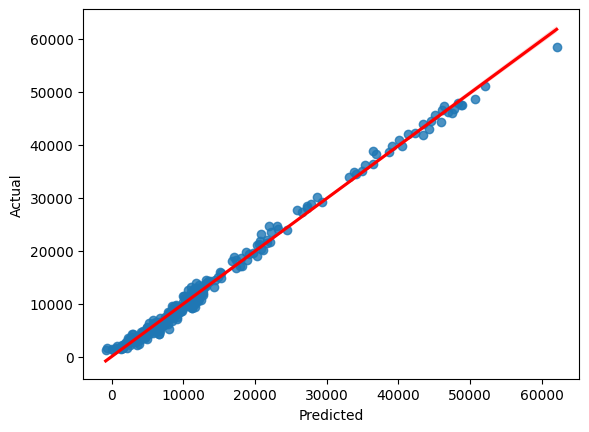

In [142]:
sb.regplot(x=y_pred,y=y_test,line_kws={"color":"red"})
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()